# ClarityNet: Preliminaary Hyperparameter Sweep for FullSubNet

The goal is to:
- find a stable baseline
- avoid over-searching
- keep the sweep small enough for a class project
- produce results to later cite in your report

In [1]:
%load_ext autoreload
%autoreload 2

import os
import json
import sys
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt


# For module imports
PROJECT_ROOT = Path("../").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.manifest import load_manifest
from src.data.dataset import FullSubNetDataset
from src.models.fullsubnet import FullSubNet
from src.training.losses import get_loss_fn
from src.evaluation.metrics import evaluate_with_metrics

✓ Dataset classes defined


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")

Device: cuda
PyTorch  : 2.10.0+cu128
CUDA     : True
GPU      : NVIDIA GeForce RTX 2080 SUPER


## Configuration

In [3]:
# Paths
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
RESULTS_DIR = PROJECT_ROOT / "results" / "sweeps" / "fullsubnet"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SWEEP_CSV = RESULTS_DIR / "sweep_results.csv"

## Create Datasets

In [4]:
# Load manifest
print("Loading manifest...")

manifest = load_manifest()

clean_train = manifest["train"]
clean_val = manifest["val"]

noise_seen = manifest["noise_seen"]
noise_unseen = manifest["noise_unseen"]

print(f"✓ Manifest loaded.")

Loading manifest...
✓ Manifest loaded.


In [5]:
from torch.utils.data import DataLoader

def make_loaders(batch_size, base_seed=42):
    train_dataset = FullSubNetDataset(
        clean_files=clean_train,
        noise_files=noise_seen,
        mode="train",
        augmentation_factor=2,
        base_seed=base_seed,
    )

    val_seen_dataset = FullSubNetDataset(
        clean_files=clean_val,
        noise_files=noise_seen,
        mode="val",
        base_seed=base_seed,
    )

    val_unseen_dataset = FullSubNetDataset(
        clean_files=clean_val,
        noise_files=noise_unseen,
        mode="val",
        base_seed=base_seed + 1,
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_seen_loader = DataLoader(val_seen_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    val_unseen_loader = DataLoader(val_unseen_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    return train_dataset, train_loader, val_seen_loader, val_unseen_loader

## Model Builder

In [6]:
def build_model(dropout=0.1):
    model = FullSubNet(
        dropout=dropout,
    )
    return model.to(DEVICE)

## Optimizer/Scheduler Builder

In [7]:
def build_optimizer(model, lr, weight_decay=1e-5):
    return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

def build_scheduler(optimizer):
    return torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2,
    )

## Training Setup

In [8]:
import gc
import torch.nn as nn

from tqdm import tqdm

def train_one_run(config):
    set_seed(config["seed"])

    train_dataset, train_loader, val_seen_loader, val_unseen_loader = make_loaders(
        batch_size=config["batch_size"],
        base_seed=config["seed"],
    )

    model = build_model(dropout=config["dropout"])
    optimizer = build_optimizer(model, lr=config["lr"], weight_decay=config["weight_decay"])
    scheduler = build_scheduler(optimizer)
    loss_fn = get_loss_fn(config["loss_name"])

    best_unseen_pesq = -np.inf
    best_unseen_si_snr = -np.inf
    best_results = None
    history = []

    for epoch in range(config["epochs"]):
        model.train()
        train_dataset.set_epoch(epoch)

        total_train_loss = 0.0
        n_batches = 0

        pbar = tqdm(train_loader, desc=f"({config['run_id']}) Epoch {epoch+1}/{config['epochs']}")
    
        for batch_idx, batch in enumerate(pbar):
            noisy = batch["noisy"].to(DEVICE)
            clean = batch["clean"].to(DEVICE)

            optimizer.zero_grad()
            pred = model(noisy)
            loss = loss_fn(pred, clean.unsqueeze(1))
            loss.backward()

            if config["grad_clip"] is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), config["grad_clip"])

            optimizer.step()

            total_train_loss += loss.item()
            n_batches += 1

        train_loss = total_train_loss / max(n_batches, 1)

        val_seen = evaluate_with_metrics(
            model, val_seen_loader, device=DEVICE, desc="Val (Seen)"
        )
        val_unseen = evaluate_with_metrics(
            model, val_unseen_loader, device=DEVICE, desc="Val (Unseen)"
        )

        scheduler.step(val_seen["mse"])

        row = {
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_seen_mse": val_seen["mse"],
            "val_unseen_mse": val_unseen["mse"],
            "val_seen_pesq": val_seen["pesq_mean"],
            "val_unseen_pesq": val_unseen["pesq_mean"],
            "val_seen_stoi": val_seen["stoi_mean"],
            "val_unseen_stoi": val_unseen["stoi_mean"],
            "val_seen_si_snr": val_seen.get("si_snr_mean", np.nan),
            "val_unseen_si_snr": val_unseen.get("si_snr_mean", np.nan),
            "pesq_gap": val_seen["pesq_mean"] - val_unseen["pesq_mean"],
            "stoi_gap": val_seen["stoi_mean"] - val_unseen["stoi_mean"],
            "si_snr_gap": val_seen.get("si_snr_mean", np.nan) - val_unseen.get("si_snr_mean", np.nan),
        }
        history.append(row)

        if val_unseen["pesq_mean"] > best_unseen_pesq and val_unseen["si_snr_mean"] > best_unseen_si_snr:
            best_unseen_pesq = val_unseen["pesq_mean"]
            best_results = row.copy()

    # cleanup before returning
    del model
    del optimizer
    if "scheduler" in locals():
        del scheduler
    if "train_loader" in locals():
        del train_loader
    if "val_seen_loader" in locals():
        del val_seen_loader
    if "val_unseen_loader" in locals():
        del val_unseen_loader
    if "train_dataset" in locals():
        del train_dataset
    if "val_seen_dataset" in locals():
        del val_seen_dataset
    if "val_unseen_dataset" in locals():
        del val_unseen_dataset

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "config": config,
        "best_unseen_pesq": best_unseen_pesq,
        "best_unseen_si_snr": best_unseen_si_snr,
        "best_results": best_results,
        "history": history,
    }

    

## Sweep Runner

In [9]:
def run_sweep(configs):
    all_results = []

    for i, config in enumerate(configs, start=1):
        print("=" * 80)
        print(f"Running config {i}/{len(configs)}: {config}")
        print("=" * 80)

        start = time.time()
        result = train_one_run(config)
        elapsed = time.time() - start

        summary = {
            "run_id": config["run_id"],
            "lr": config["lr"],
            "dropout": config["dropout"],
            "batch_size": config["batch_size"],
            "epochs": config["epochs"],
            "loss_name": config["loss_name"],
            "best_unseen_pesq": result["best_results"]["val_unseen_pesq"],
            "best_unseen_stoi": result["best_results"]["val_unseen_stoi"],
            "best_seen_pesq": result["best_results"]["val_seen_pesq"],
            "best_seen_stoi": result["best_results"]["val_seen_stoi"],
            "best_seen_si_snr": result["best_results"].get("val_seen_si_snr", np.nan),
            "best_unseen_si_snr": result["best_results"].get("val_unseen_si_snr", np.nan),
            "pesq_gap": result["best_results"]["pesq_gap"],
            "stoi_gap": result["best_results"]["stoi_gap"],
            "si_snr_gap": result["best_results"].get("si_snr_gap", np.nan),
            "runtime_sec": elapsed,
        }

        all_results.append(summary)
    
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    df = pd.DataFrame(all_results).sort_values("best_unseen_pesq", ascending=False)
    df.to_csv(SWEEP_CSV, index=False, mode="a")
    return df

## Hyperparameter Sweeps

Staged hyperparameter sweep doing:
1. Stage A: learning rate
2. Stage B: dropout
3. Stage C: batch size

### Stage A: Learning Rates

In [10]:
stage_a_configs = [
    {"run_id": "A1", "lr": 1e-4, "dropout": 0.1, "batch_size": 8, "epochs": 8, "weight_decay": 1e-5, "optimizer": "adamw", "loss_name": "mag_l1", "grad_clip": 5.0, "seed": 42},
    {"run_id": "A2", "lr": 3e-4, "dropout": 0.1, "batch_size": 8, "epochs": 8, "weight_decay": 1e-5, "optimizer": "adamw", "loss_name": "mag_l1", "grad_clip": 5.0, "seed": 42},
    {"run_id": "A3", "lr": 1e-3, "dropout": 0.1, "batch_size": 8, "epochs": 8, "weight_decay": 1e-5, "optimizer": "adamw", "loss_name": "mag_l1", "grad_clip": 5.0, "seed": 42},
]

In [11]:
df_a = run_sweep(stage_a_configs)
df_a

Running config 1/3: {'run_id': 'A1', 'lr': 0.0001, 'dropout': 0.1, 'batch_size': 8, 'epochs': 8, 'weight_decay': 1e-05, 'optimizer': 'adamw', 'loss_name': 'mag_l1', 'grad_clip': 5.0, 'seed': 42}
[FullSubNet-TRAIN] Loading 160 clean files...
[FullSubNet-TRAIN] Loading 38 noise files...
[FullSubNet-TRAIN] 285 clean segments, 76 noise segments
[FullSubNet-TRAIN] Initial train SNR range: (0, 20)
[FullSubNet-VAL] Loading 20 clean files...
[FullSubNet-VAL] Loading 38 noise files...
[FullSubNet-VAL] 36 clean segments, 76 noise segments
[FullSubNet-VAL] Generating deterministic fixed pairs (eval_pairs_per_clean=1)...
[FullSubNet-VAL] Total fixed pairs: 36
[FullSubNet-VAL] Loading 20 clean files...
[FullSubNet-VAL] Loading 22 noise files...
[FullSubNet-VAL] 36 clean segments, 44 noise segments
[FullSubNet-VAL] Generating deterministic fixed pairs (eval_pairs_per_clean=1)...
[FullSubNet-VAL] Total fixed pairs: 36


Val (Unseen): 100%|██████████| 5/5 [00:03<00:00,  1.59it/s]


Running config 2/3: {'run_id': 'A2', 'lr': 0.0003, 'dropout': 0.1, 'batch_size': 8, 'epochs': 8, 'weight_decay': 1e-05, 'optimizer': 'adamw', 'loss_name': 'mag_l1', 'grad_clip': 5.0, 'seed': 42}
[FullSubNet-TRAIN] Loading 160 clean files...
[FullSubNet-TRAIN] Loading 38 noise files...
[FullSubNet-TRAIN] 285 clean segments, 76 noise segments
[FullSubNet-TRAIN] Initial train SNR range: (0, 20)
[FullSubNet-VAL] Loading 20 clean files...
[FullSubNet-VAL] Loading 38 noise files...
[FullSubNet-VAL] 36 clean segments, 76 noise segments
[FullSubNet-VAL] Generating deterministic fixed pairs (eval_pairs_per_clean=1)...
[FullSubNet-VAL] Total fixed pairs: 36
[FullSubNet-VAL] Loading 20 clean files...
[FullSubNet-VAL] Loading 22 noise files...
[FullSubNet-VAL] 36 clean segments, 44 noise segments
[FullSubNet-VAL] Generating deterministic fixed pairs (eval_pairs_per_clean=1)...
[FullSubNet-VAL] Total fixed pairs: 36


Val (Unseen): 100%|██████████| 5/5 [00:03<00:00,  1.66it/s]


Running config 3/3: {'run_id': 'A3', 'lr': 0.001, 'dropout': 0.1, 'batch_size': 8, 'epochs': 8, 'weight_decay': 1e-05, 'optimizer': 'adamw', 'loss_name': 'mag_l1', 'grad_clip': 5.0, 'seed': 42}
[FullSubNet-TRAIN] Loading 160 clean files...
[FullSubNet-TRAIN] Loading 38 noise files...
[FullSubNet-TRAIN] 285 clean segments, 76 noise segments
[FullSubNet-TRAIN] Initial train SNR range: (0, 20)
[FullSubNet-VAL] Loading 20 clean files...
[FullSubNet-VAL] Loading 38 noise files...
[FullSubNet-VAL] 36 clean segments, 76 noise segments
[FullSubNet-VAL] Generating deterministic fixed pairs (eval_pairs_per_clean=1)...
[FullSubNet-VAL] Total fixed pairs: 36
[FullSubNet-VAL] Loading 20 clean files...
[FullSubNet-VAL] Loading 22 noise files...
[FullSubNet-VAL] 36 clean segments, 44 noise segments
[FullSubNet-VAL] Generating deterministic fixed pairs (eval_pairs_per_clean=1)...
[FullSubNet-VAL] Total fixed pairs: 36


Val (Unseen): 100%|██████████| 5/5 [00:03<00:00,  1.65it/s]


,run_id,lr,dropout,batch_size,epochs,loss_name,best_unseen_pesq,best_unseen_stoi,best_seen_pesq,best_seen_stoi,best_seen_si_snr,best_unseen_si_snr,pesq_gap,stoi_gap,si_snr_gap,runtime_sec
1,A2,0.0003,0.1,8,8,mag_l1,2.683692,0.897734,2.684912,0.886539,15.005847,15.878582,0.001220,-0.011195,-0.872735,366.770127
0,A1,0.0001,0.1,8,8,mag_l1,2.585804,0.889172,2.619294,0.880592,13.829508,14.407199,0.033490,-0.008580,-0.577691,386.023438
2,A3,0.0010,0.1,8,8,mag_l1,2.561147,0.895951,2.526196,0.884943,12.762251,14.299763,-0.034952,-0.011007,-1.537513,358.066487


Best LR: `3e-4`

### Stage B: Dropout

In [12]:
best_lr = 3e-4

stage_b_configs = [
    {"run_id": "B1", "lr": best_lr, "dropout": 0.0, "batch_size": 8, "epochs": 8, "weight_decay": 1e-5, "optimizer": "adamw", "loss_name": "mag_l1", "grad_clip": 5.0, "seed": 42},
    {"run_id": "B2", "lr": best_lr, "dropout": 0.1, "batch_size": 8, "epochs": 8, "weight_decay": 1e-5, "optimizer": "adamw", "loss_name": "mag_l1", "grad_clip": 5.0, "seed": 42},
    {"run_id": "B3", "lr": best_lr, "dropout": 0.2, "batch_size": 8, "epochs": 8, "weight_decay": 1e-5, "optimizer": "adamw", "loss_name": "mag_l1", "grad_clip": 5.0, "seed": 42},
]

In [13]:
df_b = run_sweep(stage_b_configs)
df_b

Running config 1/3: {'run_id': 'B1', 'lr': 0.0003, 'dropout': 0.0, 'batch_size': 8, 'epochs': 8, 'weight_decay': 1e-05, 'optimizer': 'adamw', 'loss_name': 'mag_l1', 'grad_clip': 5.0, 'seed': 42}
[FullSubNet-TRAIN] Loading 160 clean files...
[FullSubNet-TRAIN] Loading 38 noise files...
[FullSubNet-TRAIN] 285 clean segments, 76 noise segments
[FullSubNet-TRAIN] Initial train SNR range: (0, 20)
[FullSubNet-VAL] Loading 20 clean files...
[FullSubNet-VAL] Loading 38 noise files...
[FullSubNet-VAL] 36 clean segments, 76 noise segments
[FullSubNet-VAL] Generating deterministic fixed pairs (eval_pairs_per_clean=1)...
[FullSubNet-VAL] Total fixed pairs: 36
[FullSubNet-VAL] Loading 20 clean files...
[FullSubNet-VAL] Loading 22 noise files...
[FullSubNet-VAL] 36 clean segments, 44 noise segments
[FullSubNet-VAL] Generating deterministic fixed pairs (eval_pairs_per_clean=1)...
[FullSubNet-VAL] Total fixed pairs: 36


Val (Unseen): 100%|██████████| 5/5 [00:02<00:00,  1.69it/s]


Running config 2/3: {'run_id': 'B2', 'lr': 0.0003, 'dropout': 0.1, 'batch_size': 8, 'epochs': 8, 'weight_decay': 1e-05, 'optimizer': 'adamw', 'loss_name': 'mag_l1', 'grad_clip': 5.0, 'seed': 42}
[FullSubNet-TRAIN] Loading 160 clean files...
[FullSubNet-TRAIN] Loading 38 noise files...
[FullSubNet-TRAIN] 285 clean segments, 76 noise segments
[FullSubNet-TRAIN] Initial train SNR range: (0, 20)
[FullSubNet-VAL] Loading 20 clean files...
[FullSubNet-VAL] Loading 38 noise files...
[FullSubNet-VAL] 36 clean segments, 76 noise segments
[FullSubNet-VAL] Generating deterministic fixed pairs (eval_pairs_per_clean=1)...
[FullSubNet-VAL] Total fixed pairs: 36
[FullSubNet-VAL] Loading 20 clean files...
[FullSubNet-VAL] Loading 22 noise files...
[FullSubNet-VAL] 36 clean segments, 44 noise segments
[FullSubNet-VAL] Generating deterministic fixed pairs (eval_pairs_per_clean=1)...
[FullSubNet-VAL] Total fixed pairs: 36


Val (Unseen): 100%|██████████| 5/5 [00:03<00:00,  1.66it/s]


Running config 3/3: {'run_id': 'B3', 'lr': 0.0003, 'dropout': 0.2, 'batch_size': 8, 'epochs': 8, 'weight_decay': 1e-05, 'optimizer': 'adamw', 'loss_name': 'mag_l1', 'grad_clip': 5.0, 'seed': 42}
[FullSubNet-TRAIN] Loading 160 clean files...
[FullSubNet-TRAIN] Loading 38 noise files...
[FullSubNet-TRAIN] 285 clean segments, 76 noise segments
[FullSubNet-TRAIN] Initial train SNR range: (0, 20)
[FullSubNet-VAL] Loading 20 clean files...
[FullSubNet-VAL] Loading 38 noise files...
[FullSubNet-VAL] 36 clean segments, 76 noise segments
[FullSubNet-VAL] Generating deterministic fixed pairs (eval_pairs_per_clean=1)...
[FullSubNet-VAL] Total fixed pairs: 36
[FullSubNet-VAL] Loading 20 clean files...
[FullSubNet-VAL] Loading 22 noise files...
[FullSubNet-VAL] 36 clean segments, 44 noise segments
[FullSubNet-VAL] Generating deterministic fixed pairs (eval_pairs_per_clean=1)...
[FullSubNet-VAL] Total fixed pairs: 36


Val (Unseen): 100%|██████████| 5/5 [00:03<00:00,  1.64it/s]


,run_id,lr,dropout,batch_size,epochs,loss_name,best_unseen_pesq,best_unseen_stoi,best_seen_pesq,best_seen_stoi,best_seen_si_snr,best_unseen_si_snr,pesq_gap,stoi_gap,si_snr_gap,runtime_sec
1,B2,0.0003,0.1,8,8,mag_l1,2.683692,0.897734,2.684912,0.886539,15.005847,15.878582,0.001220,-0.011195,-0.872735,356.583922
2,B3,0.0003,0.2,8,8,mag_l1,2.661882,0.893827,2.614855,0.881234,14.514619,15.578518,-0.047027,-0.012593,-1.063899,358.748343
0,B1,0.0003,0.0,8,8,mag_l1,2.651895,0.893766,2.690942,0.887065,14.843671,15.384043,0.039047,-0.006701,-0.540371,353.374607


Best dropout: `0.1`

### Stage C: Batch Size

In [14]:
best_dropout = 0.1

stage_c_configs = [
    {"run_id": "C1", "lr": best_lr, "dropout": best_dropout, "batch_size": 4, "epochs": 8, "weight_decay": 1e-5, "optimizer": "adamw", "loss_name": "mag_l1", "grad_clip": 5.0, "seed": 42},
    {"run_id": "C2", "lr": best_lr, "dropout": best_dropout, "batch_size": 8, "epochs": 8, "weight_decay": 1e-5, "optimizer": "adamw", "loss_name": "mag_l1", "grad_clip": 5.0, "seed": 42},
]

In [15]:
df_c = run_sweep(stage_c_configs)
df_c

Running config 1/2: {'run_id': 'C1', 'lr': 0.0003, 'dropout': 0.1, 'batch_size': 4, 'epochs': 8, 'weight_decay': 1e-05, 'optimizer': 'adamw', 'loss_name': 'mag_l1', 'grad_clip': 5.0, 'seed': 42}
[FullSubNet-TRAIN] Loading 160 clean files...
[FullSubNet-TRAIN] Loading 38 noise files...
[FullSubNet-TRAIN] 285 clean segments, 76 noise segments
[FullSubNet-TRAIN] Initial train SNR range: (0, 20)
[FullSubNet-VAL] Loading 20 clean files...
[FullSubNet-VAL] Loading 38 noise files...
[FullSubNet-VAL] 36 clean segments, 76 noise segments
[FullSubNet-VAL] Generating deterministic fixed pairs (eval_pairs_per_clean=1)...
[FullSubNet-VAL] Total fixed pairs: 36
[FullSubNet-VAL] Loading 20 clean files...
[FullSubNet-VAL] Loading 22 noise files...
[FullSubNet-VAL] 36 clean segments, 44 noise segments
[FullSubNet-VAL] Generating deterministic fixed pairs (eval_pairs_per_clean=1)...
[FullSubNet-VAL] Total fixed pairs: 36


Val (Unseen): 100%|██████████| 9/9 [00:03<00:00,  2.48it/s]


Running config 2/2: {'run_id': 'C2', 'lr': 0.0003, 'dropout': 0.1, 'batch_size': 8, 'epochs': 8, 'weight_decay': 1e-05, 'optimizer': 'adamw', 'loss_name': 'mag_l1', 'grad_clip': 5.0, 'seed': 42}
[FullSubNet-TRAIN] Loading 160 clean files...
[FullSubNet-TRAIN] Loading 38 noise files...
[FullSubNet-TRAIN] 285 clean segments, 76 noise segments
[FullSubNet-TRAIN] Initial train SNR range: (0, 20)
[FullSubNet-VAL] Loading 20 clean files...
[FullSubNet-VAL] Loading 38 noise files...
[FullSubNet-VAL] 36 clean segments, 76 noise segments
[FullSubNet-VAL] Generating deterministic fixed pairs (eval_pairs_per_clean=1)...
[FullSubNet-VAL] Total fixed pairs: 36
[FullSubNet-VAL] Loading 20 clean files...
[FullSubNet-VAL] Loading 22 noise files...
[FullSubNet-VAL] 36 clean segments, 44 noise segments
[FullSubNet-VAL] Generating deterministic fixed pairs (eval_pairs_per_clean=1)...
[FullSubNet-VAL] Total fixed pairs: 36


Val (Unseen): 100%|██████████| 5/5 [00:03<00:00,  1.60it/s]


,run_id,lr,dropout,batch_size,epochs,loss_name,best_unseen_pesq,best_unseen_stoi,best_seen_pesq,best_seen_stoi,best_seen_si_snr,best_unseen_si_snr,pesq_gap,stoi_gap,si_snr_gap,runtime_sec
1,C2,0.0003,0.1,8,8,mag_l1,2.683692,0.897734,2.684912,0.886539,15.005847,15.878582,0.001220,-0.011195,-0.872735,387.571120
0,C1,0.0003,0.1,4,8,mag_l1,2.671057,0.898334,2.640551,0.888504,15.536821,16.051977,-0.030505,-0.009829,-0.515155,452.889408


Best batch size: `8`

#### Stage D: Compare original learning rate with new learning rate

In [19]:
stage_d_configs = [
    {"run_id": "D1", "lr": 3e-4, "dropout": 0.1, "batch_size": 8, "epochs": 15, "weight_decay": 1e-5, "optimizer": "adamw", "loss_name": "mag_l1", "grad_clip": 5.0, "seed": 42},
    {"run_id": "D2", "lr": 5e-4, "dropout": 0.1, "batch_size": 8, "epochs": 15, "weight_decay": 1e-5, "optimizer": "adamw", "loss_name": "mag_l1", "grad_clip": 5.0, "seed": 42},
]

In [20]:
df_d = run_sweep(stage_d_configs)
df_d

Running config 1/2: {'run_id': 'D1', 'lr': 0.0003, 'dropout': 0.1, 'batch_size': 8, 'epochs': 15, 'weight_decay': 1e-05, 'optimizer': 'adamw', 'loss_name': 'mag_l1', 'grad_clip': 5.0, 'seed': 42}
[FullSubNet-TRAIN] Loading 160 clean files...
[FullSubNet-TRAIN] Loading 38 noise files...
[FullSubNet-TRAIN] 285 clean segments, 76 noise segments
[FullSubNet-TRAIN] Initial train SNR range: (0, 20)
[FullSubNet-VAL] Loading 20 clean files...
[FullSubNet-VAL] Loading 38 noise files...
[FullSubNet-VAL] 36 clean segments, 76 noise segments
[FullSubNet-VAL] Generating deterministic fixed pairs (eval_pairs_per_clean=1)...
[FullSubNet-VAL] Total fixed pairs: 36
[FullSubNet-VAL] Loading 20 clean files...
[FullSubNet-VAL] Loading 22 noise files...
[FullSubNet-VAL] 36 clean segments, 44 noise segments
[FullSubNet-VAL] Generating deterministic fixed pairs (eval_pairs_per_clean=1)...
[FullSubNet-VAL] Total fixed pairs: 36


Val (Unseen): 100%|██████████| 5/5 [00:02<00:00,  1.71it/s]


Running config 2/2: {'run_id': 'D2', 'lr': 0.0005, 'dropout': 0.1, 'batch_size': 8, 'epochs': 15, 'weight_decay': 1e-05, 'optimizer': 'adamw', 'loss_name': 'mag_l1', 'grad_clip': 5.0, 'seed': 42}
[FullSubNet-TRAIN] Loading 160 clean files...
[FullSubNet-TRAIN] Loading 38 noise files...
[FullSubNet-TRAIN] 285 clean segments, 76 noise segments
[FullSubNet-TRAIN] Initial train SNR range: (0, 20)
[FullSubNet-VAL] Loading 20 clean files...
[FullSubNet-VAL] Loading 38 noise files...
[FullSubNet-VAL] 36 clean segments, 76 noise segments
[FullSubNet-VAL] Generating deterministic fixed pairs (eval_pairs_per_clean=1)...
[FullSubNet-VAL] Total fixed pairs: 36
[FullSubNet-VAL] Loading 20 clean files...
[FullSubNet-VAL] Loading 22 noise files...
[FullSubNet-VAL] 36 clean segments, 44 noise segments
[FullSubNet-VAL] Generating deterministic fixed pairs (eval_pairs_per_clean=1)...
[FullSubNet-VAL] Total fixed pairs: 36


Val (Unseen): 100%|██████████| 5/5 [00:03<00:00,  1.55it/s]


,run_id,lr,dropout,batch_size,epochs,loss_name,best_unseen_pesq,best_unseen_stoi,best_seen_pesq,best_seen_stoi,best_seen_si_snr,best_unseen_si_snr,pesq_gap,stoi_gap,si_snr_gap,runtime_sec
1,D2,0.0005,0.1,8,15,mag_l1,2.799450,0.902891,2.782596,0.892890,16.570078,16.967963,-0.016853,-0.010002,-0.397885,765.485608
0,D1,0.0003,0.1,8,15,mag_l1,2.765884,0.899170,2.754212,0.890116,16.150403,16.742706,-0.011672,-0.009054,-0.592303,730.433967


### Stage E: Another experiment

In [21]:
stage_e_configs = [
    {"run_id": "D1", "lr": 5e-4, "dropout": 0.0, "batch_size": 8, "epochs": 15, "weight_decay": 1e-5, "optimizer": "adamw", "loss_name": "mag_l1", "grad_clip": 5.0, "seed": 42},
    {"run_id": "D2", "lr": 3e-4, "dropout": 0.0, "batch_size": 8, "epochs": 15, "weight_decay": 1e-5, "optimizer": "adamw", "loss_name": "mag_l1", "grad_clip": 5.0, "seed": 42},
]

In [22]:
df_e = run_sweep(stage_e_configs)
df_e

Running config 1/2: {'run_id': 'D1', 'lr': 0.0005, 'dropout': 0.0, 'batch_size': 8, 'epochs': 15, 'weight_decay': 1e-05, 'optimizer': 'adamw', 'loss_name': 'mag_l1', 'grad_clip': 5.0, 'seed': 42}
[FullSubNet-TRAIN] Loading 160 clean files...
[FullSubNet-TRAIN] Loading 38 noise files...
[FullSubNet-TRAIN] 285 clean segments, 76 noise segments
[FullSubNet-TRAIN] Initial train SNR range: (0, 20)
[FullSubNet-VAL] Loading 20 clean files...
[FullSubNet-VAL] Loading 38 noise files...
[FullSubNet-VAL] 36 clean segments, 76 noise segments
[FullSubNet-VAL] Generating deterministic fixed pairs (eval_pairs_per_clean=1)...
[FullSubNet-VAL] Total fixed pairs: 36
[FullSubNet-VAL] Loading 20 clean files...
[FullSubNet-VAL] Loading 22 noise files...
[FullSubNet-VAL] 36 clean segments, 44 noise segments
[FullSubNet-VAL] Generating deterministic fixed pairs (eval_pairs_per_clean=1)...
[FullSubNet-VAL] Total fixed pairs: 36


Val (Unseen): 100%|██████████| 5/5 [00:03<00:00,  1.57it/s]


Running config 2/2: {'run_id': 'D2', 'lr': 0.0003, 'dropout': 0.0, 'batch_size': 8, 'epochs': 15, 'weight_decay': 1e-05, 'optimizer': 'adamw', 'loss_name': 'mag_l1', 'grad_clip': 5.0, 'seed': 42}
[FullSubNet-TRAIN] Loading 160 clean files...
[FullSubNet-TRAIN] Loading 38 noise files...
[FullSubNet-TRAIN] 285 clean segments, 76 noise segments
[FullSubNet-TRAIN] Initial train SNR range: (0, 20)
[FullSubNet-VAL] Loading 20 clean files...
[FullSubNet-VAL] Loading 38 noise files...
[FullSubNet-VAL] 36 clean segments, 76 noise segments
[FullSubNet-VAL] Generating deterministic fixed pairs (eval_pairs_per_clean=1)...
[FullSubNet-VAL] Total fixed pairs: 36
[FullSubNet-VAL] Loading 20 clean files...
[FullSubNet-VAL] Loading 22 noise files...
[FullSubNet-VAL] 36 clean segments, 44 noise segments
[FullSubNet-VAL] Generating deterministic fixed pairs (eval_pairs_per_clean=1)...
[FullSubNet-VAL] Total fixed pairs: 36


Val (Unseen): 100%|██████████| 5/5 [00:02<00:00,  1.76it/s]


,run_id,lr,dropout,batch_size,epochs,loss_name,best_unseen_pesq,best_unseen_stoi,best_seen_pesq,best_seen_stoi,best_seen_si_snr,best_unseen_si_snr,pesq_gap,stoi_gap,si_snr_gap,runtime_sec
1,D2,0.0003,0.0,8,15,mag_l1,2.800389,0.903128,2.840103,0.898565,17.287936,16.858571,0.039714,-0.004563,0.429365,655.051066
0,D1,0.0005,0.0,8,15,mag_l1,2.696186,0.900210,2.697531,0.890712,15.236320,16.011742,0.001345,-0.009498,-0.775423,775.149940


## Compare results

In [16]:
df_all = pd.concat([df_a, df_b, df_c], ignore_index=True)
df_all = df_all.sort_values("best_unseen_pesq", ascending=False)
df_all

,run_id,lr,dropout,batch_size,epochs,loss_name,best_unseen_pesq,best_unseen_stoi,best_seen_pesq,best_seen_stoi,best_seen_si_snr,best_unseen_si_snr,pesq_gap,stoi_gap,si_snr_gap,runtime_sec
0,A2,0.0003,0.1,8,8,mag_l1,2.683692,0.897734,2.684912,0.886539,15.005847,15.878582,0.001220,-0.011195,-0.872735,366.770127
3,B2,0.0003,0.1,8,8,mag_l1,2.683692,0.897734,2.684912,0.886539,15.005847,15.878582,0.001220,-0.011195,-0.872735,356.583922
6,C2,0.0003,0.1,8,8,mag_l1,2.683692,0.897734,2.684912,0.886539,15.005847,15.878582,0.001220,-0.011195,-0.872735,387.571120
7,C1,0.0003,0.1,4,8,mag_l1,2.671057,0.898334,2.640551,0.888504,15.536821,16.051977,-0.030505,-0.009829,-0.515155,452.889408
4,B3,0.0003,0.2,8,8,mag_l1,2.661882,0.893827,2.614855,0.881234,14.514619,15.578518,-0.047027,-0.012593,-1.063899,358.748343
5,B1,0.0003,0.0,8,8,mag_l1,2.651895,0.893766,2.690942,0.887065,14.843671,15.384043,0.039047,-0.006701,-0.540371,353.374607
1,A1,0.0001,0.1,8,8,mag_l1,2.585804,0.889172,2.619294,0.880592,13.829508,14.407199,0.033490,-0.008580,-0.577691,386.023438
2,A3,0.0010,0.1,8,8,mag_l1,2.561147,0.895951,2.526196,0.884943,12.762251,14.299763,-0.034952,-0.011007,-1.537513,358.066487


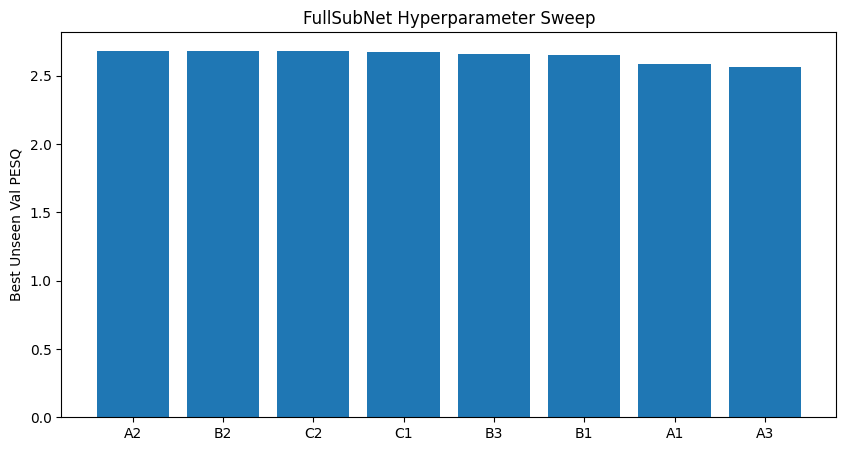

In [17]:
plt.figure(figsize=(10, 5))
plt.bar(df_all["run_id"], df_all["best_unseen_pesq"])
plt.ylabel("Best Unseen Val PESQ")
plt.title("FullSubNet Hyperparameter Sweep")
plt.show()

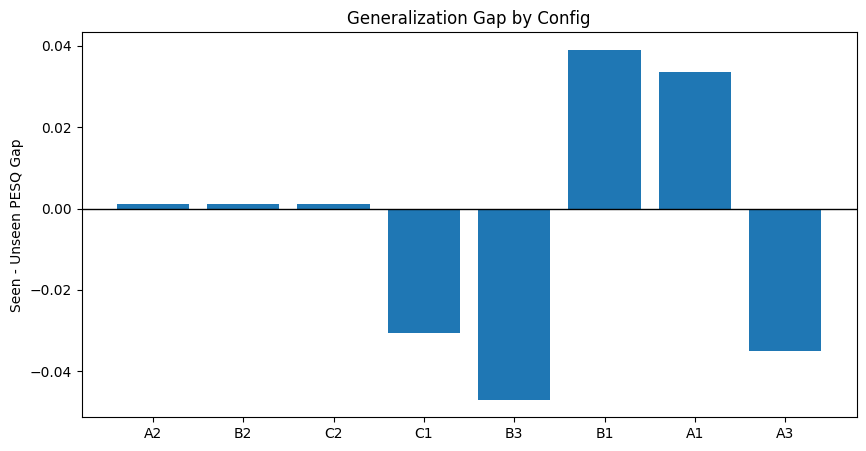

In [18]:
plt.figure(figsize=(10, 5))
plt.bar(df_all["run_id"], df_all["pesq_gap"])
plt.ylabel("Seen - Unseen PESQ Gap")
plt.title("Generalization Gap by Config")
plt.axhline(0, color="black", linewidth=1)
plt.show()

In [28]:
df_final = pd.concat([df_all, df_d, df_e], ignore_index=True).sort_values("best_unseen_pesq", ascending=False)
df_final.to_csv(SWEEP_CSV, index=False, mode="w")
df_final

,run_id,lr,dropout,batch_size,epochs,loss_name,best_unseen_pesq,best_unseen_stoi,best_seen_pesq,best_seen_stoi,best_seen_si_snr,best_unseen_si_snr,pesq_gap,stoi_gap,si_snr_gap,runtime_sec
10,D2,0.0003,0.0,8,15,mag_l1,2.800389,0.903128,2.840103,0.898565,17.287936,16.858571,0.039714,-0.004563,0.429365,655.051066
8,D2,0.0005,0.1,8,15,mag_l1,2.799450,0.902891,2.782596,0.892890,16.570078,16.967963,-0.016853,-0.010002,-0.397885,765.485608
9,D1,0.0003,0.1,8,15,mag_l1,2.765884,0.899170,2.754212,0.890116,16.150403,16.742706,-0.011672,-0.009054,-0.592303,730.433967
11,D1,0.0005,0.0,8,15,mag_l1,2.696186,0.900210,2.697531,0.890712,15.236320,16.011742,0.001345,-0.009498,-0.775423,775.149940
1,B2,0.0003,0.1,8,8,mag_l1,2.683692,0.897734,2.684912,0.886539,15.005847,15.878582,0.001220,-0.011195,-0.872735,356.583922
2,C2,0.0003,0.1,8,8,mag_l1,2.683692,0.897734,2.684912,0.886539,15.005847,15.878582,0.001220,-0.011195,-0.872735,387.571120
0,A2,0.0003,0.1,8,8,mag_l1,2.683692,0.897734,2.684912,0.886539,15.005847,15.878582,0.001220,-0.011195,-0.872735,366.770127
3,C1,0.0003,0.1,4,8,mag_l1,2.671057,0.898334,2.640551,0.888504,15.536821,16.051977,-0.030505,-0.009829,-0.515155,452.889408
4,B3,0.0003,0.2,8,8,mag_l1,2.661882,0.893827,2.614855,0.881234,14.514619,15.578518,-0.047027,-0.012593,-1.063899,358.748343
5,B1,0.0003,0.0,8,8,mag_l1,2.651895,0.893766,2.690942,0.887065,14.843671,15.384043,0.039047,-0.006701,-0.540371,353.374607


## Summary

### What We've Accomplished:

1. ✅ **Tuned hyperparameters** for a more stable ablation study

### Key Observations:

- **Learning rate** was a key factor to performance
- **Dropout layers** seem to help with generalization, would make for a good ablation study
- Smaller **Batch size** underperformed

### Files Created:

- `results/sweeps/fullsubnet/sweep_results.csv` — Stored sweeps results